# 15 — Passing-Network Vulnerability: Part 5, Tactical Case Studies

*2018 & 2022 FIFA World Cup · StatsBomb event data*

**Where this fits:** Parts 1-4 built and validated the vulnerability-simulation pipeline
(baseline networks → single-player removal → targeted-vs-typical comparison → two-player
combination search). This notebook turns that machinery into an interpretable story: three
deliberately different case studies, a synergy visualization, and one summary framework
that classifies every team-match by two axes — individual concentration and pair synergy.

**Final question:** where are World Cup passing networks structurally vulnerable, and are
those vulnerabilities concentrated in obvious stars or hidden combinations of players?

**Standing caveat (same as Parts 2-4):** this is a structural disruption simulation on the
*observed* network, not a behavioral counterfactual. It does not claim that removing a
player from the real match would produce these exact numbers — it measures how much of the
network's existing structural capacity is attributable to that player or pair.

In [1]:
import sys
sys.path.insert(0, '../src')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import network_vulnerability as nv
from network_builder import build_network
from data_loader import extract_passes
from visualization import plot_pass_network

PROC_DIR = Path('../data/processed')
FIG_DIR = Path('../outputs/figures')

player_network_baseline = pd.read_csv(PROC_DIR / 'player_network_baseline.csv')
single_player_removal = pd.read_csv(PROC_DIR / 'single_player_removal.csv')
team_match_robustness = pd.read_csv(PROC_DIR / 'team_match_robustness.csv')
two_player_removal = pd.read_csv(PROC_DIR / 'two_player_removal.csv')
team_match_pair_vulnerability = pd.read_csv(PROC_DIR / 'team_match_pair_vulnerability.csv')

In [2]:
def load_match_team_passes(match_id, team, open_play_only=False):
    """Full-match completed passes for one team, from the raw event cache."""
    path = next(p for mid, yr, p in nv._match_files() if mid == match_id)
    events = pd.read_parquet(path)
    passes = extract_passes(events, open_play_only=open_play_only)
    passes['match_id'] = match_id
    return passes[passes['team'] == team].copy()


def build_disrupted_network(team_passes, match_id, team, removed_players):
    """Same network with all passes touching `removed_players` excluded —
    equivalent to G.remove_node() for each, but returns a full PassNetwork
    (with node_table) so it can be plotted directly."""
    remaining = team_passes[
        ~team_passes['player'].isin(removed_players)
        & ~team_passes['pass_recipient'].isin(removed_players)
    ]
    return build_network(remaining, match_id, team, min_passes=1)


def fixed_scale_refs(original_net):
    """Node-size and edge-width normalization taken from the ORIGINAL network,
    so before/after panels are on an identical visual scale."""
    out_degree = dict(original_net.graph.out_degree(weight='weight'))
    max_deg = max(out_degree.values()) if out_degree else 1
    max_w = original_net.edge_table['weight'].max() if not original_net.edge_table.empty else 1
    return max_deg, max_w


def shared_positions(original_net):
    pos = {}
    for _, row in original_net.node_table.iterrows():
        if pd.notna(row.get('avg_x')) and pd.notna(row.get('avg_y')):
            pos[row['player']] = (row['avg_x'], row['avg_y'])
    return pos

## 5A — Three case studies, selected from the validated Parts 1-4 output

| Case | Team-match | Selection criterion |
|---|---|---|
| 1. Hidden individual vulnerability | France vs Belgium, 2018 semi-final | Highest `efficiency_damage` in the dataset (0.128) despite ranking outside the top 5 in betweenness |
| 2. Pair synergy | Japan vs Senegal, 2018 group stage | Honda + Nagatomo: both individually ~0 damage, jointly 0.100 — the largest such gap found in Part 4 |
| 3. Robust / distributed network | England vs Tunisia, 2018 group stage | `top1_top2_gap = 0.0` (three players exactly tied for most damaging) and low pair-removal effect |

Each was pulled directly from `team_match_robustness.csv` / `two_player_removal.csv` —
nothing here is hand-picked outside what the pipeline already surfaced.

## Case 1 — Hidden individual vulnerability: N'Golo Kanté (France 2-0... 1-0 Belgium, 2018 SF)

In [3]:
c1 = team_match_robustness[
    (team_match_robustness['match_id'] == 8655) & (team_match_robustness['team'] == 'France')
].iloc[0]

fr_players = player_network_baseline[
    (player_network_baseline['match_id'] == 8655) & (player_network_baseline['team'] == 'France')
].copy()
fr_players['betweenness_rank'] = fr_players['betweenness_centrality'].rank(ascending=False, method='min')
kante_bt_rank = int(fr_players.loc[fr_players['player'] == 'N\'Golo Kanté', 'betweenness_rank'].iloc[0])

next_most_damaging = c1['targeted_efficiency_damage'] - c1['top1_top2_gap']

print(f"KANTÉ REMOVED — France vs Belgium (2018 semi-final, France won 1-0)")
print(f"  Pass involvement rank      : #{int(c1['targeted_pass_involvement_rank'])}")
print(f"  Betweenness centrality rank: #{kante_bt_rank} of {len(fr_players)}")
print(f"  Efficiency damage          : {c1['targeted_efficiency_damage']:.3f}")
print(f"  Next-most-damaging player  : {next_most_damaging:.3f}")
print(f"  Excess over typical removal: {c1['targeted_excess_efficiency_damage']:.3f}")
print(f"  Standardized gap (z-score) : {c1['targeted_standardized_gap']:.2f}")
print()
print('=> Neither the team\'s top passer nor its top-betweenness player. The network')
print('   was more structurally dependent on Kanté than on any metric that ranks players')
print('   by raw involvement or standard centrality would have suggested.')

KANTÉ REMOVED — France vs Belgium (2018 semi-final, France won 1-0)
  Pass involvement rank      : #2
  Betweenness centrality rank: #7 of 13
  Efficiency damage          : 0.128
  Next-most-damaging player  : 0.021
  Excess over typical removal: 0.115
  Standardized gap (z-score) : 2.88

=> Neither the team's top passer nor its top-betweenness player. The network
   was more structurally dependent on Kanté than on any metric that ranks players
   by raw involvement or standard centrality would have suggested.


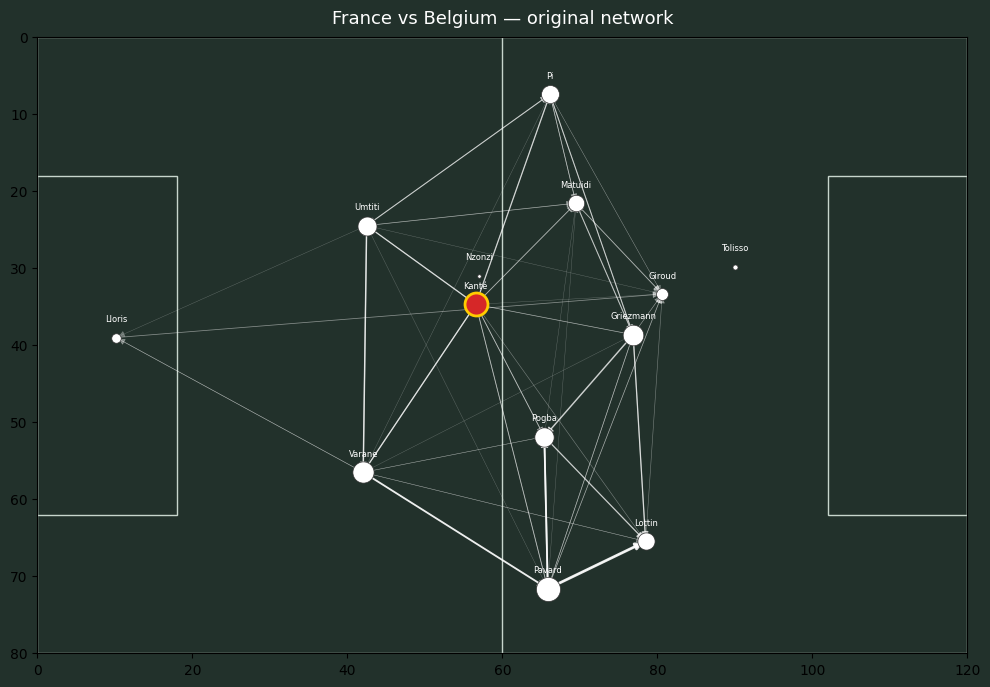

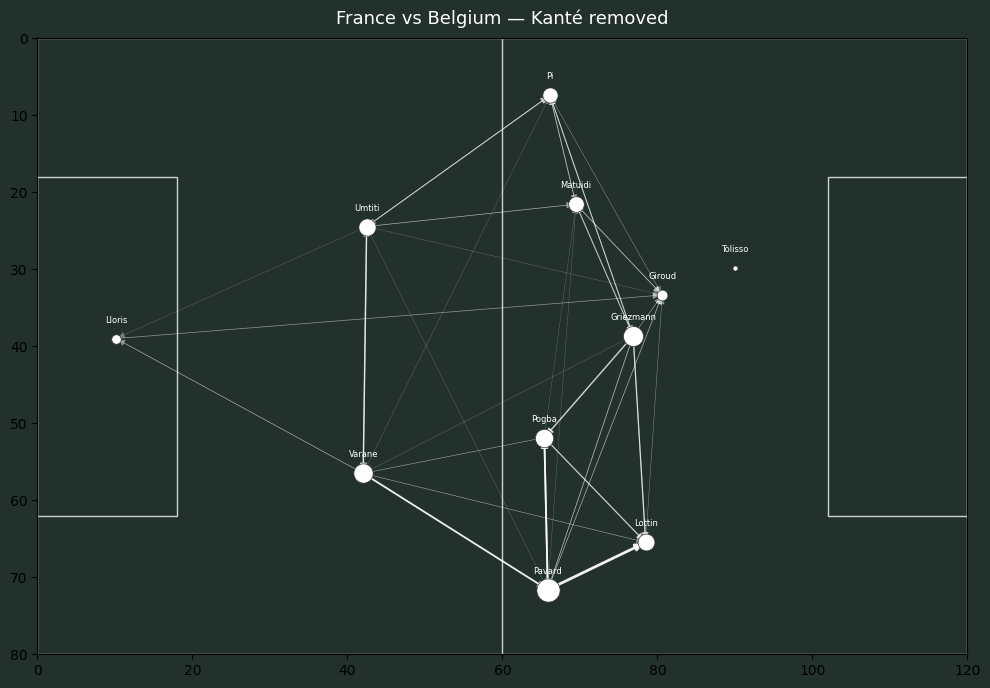

In [4]:
passes_c1 = load_match_team_passes(8655, 'France')
orig_c1 = build_network(passes_c1, 8655, 'France', min_passes=1)
removed_c1 = build_disrupted_network(passes_c1, 8655, 'France', ["N'Golo Kanté"])

max_deg_c1, max_w_c1 = fixed_scale_refs(orig_c1)
pos_c1 = shared_positions(orig_c1)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
plt.close(fig)

f1 = plot_pass_network(
    orig_c1, title='France vs Belgium — original network',
    min_edge_weight=2, max_out_degree_ref=max_deg_c1, max_edge_weight_ref=max_w_c1,
    node_positions=pos_c1, highlight_players=["N'Golo Kanté"],
    save_path=FIG_DIR / '15_case1_original.png',
)
plt.show()
plt.close(f1)

f2 = plot_pass_network(
    removed_c1, title='France vs Belgium — Kanté removed',
    min_edge_weight=2, max_out_degree_ref=max_deg_c1, max_edge_weight_ref=max_w_c1,
    node_positions=pos_c1,
    save_path=FIG_DIR / '15_case1_removed.png',
)
plt.show()
plt.close(f2)

## Case 2 — Pair synergy: Honda + Nagatomo (Japan vs Senegal, 2018, 2-2)

In [5]:
pair_row = two_player_removal[
    (two_player_removal['match_id'] == 7556) & (two_player_removal['team'] == 'Japan')
    & (two_player_removal['player_a'] == 'Keisuke Honda') & (two_player_removal['player_b'] == 'Yuto Nagatomo')
].iloc[0]

synergy_table = pd.DataFrame([
    {'Removal': 'Honda only', 'Efficiency damage': pair_row['player_a_efficiency_damage']},
    {'Removal': 'Nagatomo only', 'Efficiency damage': pair_row['player_b_efficiency_damage']},
    {'Removal': 'Expected / additive', 'Efficiency damage': pair_row['additive_expected_efficiency_damage']},
    {'Removal': 'Honda + Nagatomo (actual)', 'Efficiency damage': pair_row['joint_efficiency_damage']},
])
synergy_table['Efficiency damage'] = synergy_table['Efficiency damage'].round(4)
print(synergy_table.to_string(index=False))
print()
print(f"Interaction effect: {pair_row['interaction_effect_efficiency']:+.4f} "
      f"(joint damage is {pair_row['joint_efficiency_damage']/pair_row['additive_expected_efficiency_damage']:.1f}x "
      f"the additive expectation)")
print()
print('=> Neither player looks critical on their own. Together, they eliminate complementary')
print('   pathways the network relies on — a vulnerability invisible to single-player analysis.')

                  Removal  Efficiency damage
               Honda only             0.0000
            Nagatomo only             0.0103
      Expected / additive             0.0103
Honda + Nagatomo (actual)             0.1000

Interaction effect: +0.0897 (joint damage is 9.7x the additive expectation)

=> Neither player looks critical on their own. Together, they eliminate complementary
   pathways the network relies on — a vulnerability invisible to single-player analysis.


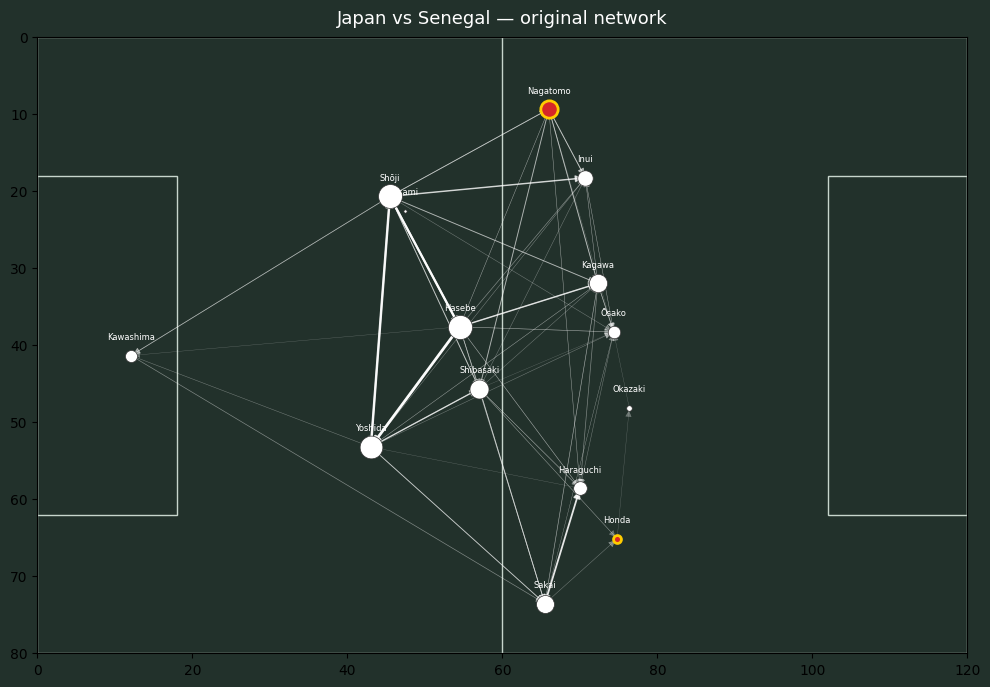

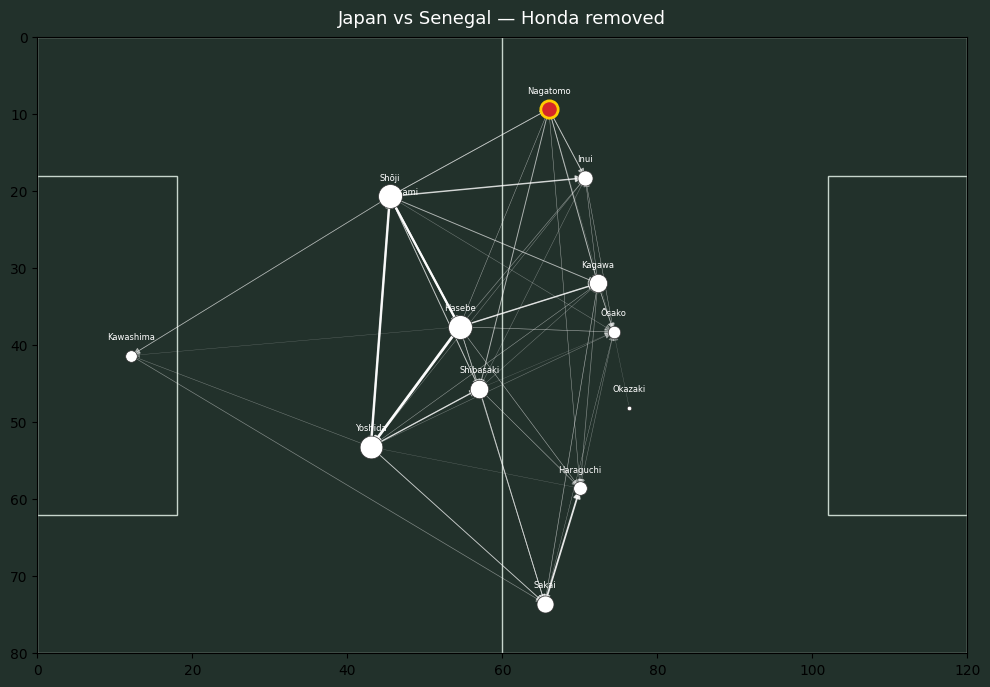

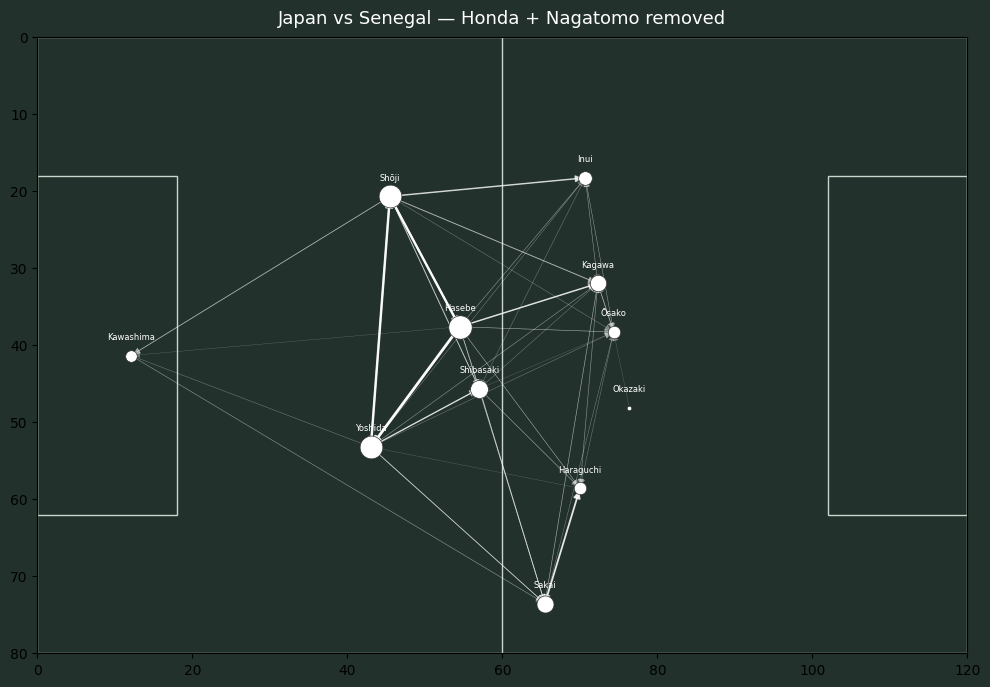

In [6]:
passes_c2 = load_match_team_passes(7556, 'Japan')
orig_c2 = build_network(passes_c2, 7556, 'Japan', min_passes=1)
minus_a_c2 = build_disrupted_network(passes_c2, 7556, 'Japan', ['Keisuke Honda'])
minus_ab_c2 = build_disrupted_network(passes_c2, 7556, 'Japan', ['Keisuke Honda', 'Yuto Nagatomo'])

max_deg_c2, max_w_c2 = fixed_scale_refs(orig_c2)
pos_c2 = shared_positions(orig_c2)

panels = [
    (orig_c2, 'Japan vs Senegal — original network', ['Keisuke Honda', 'Yuto Nagatomo'], '15_case2_original.png'),
    (minus_a_c2, 'Japan vs Senegal — Honda removed', ['Yuto Nagatomo'], '15_case2_minus_honda.png'),
    (minus_ab_c2, 'Japan vs Senegal — Honda + Nagatomo removed', [], '15_case2_minus_both.png'),
]
for net, title, highlight, fname in panels:
    f = plot_pass_network(
        net, title=title, min_edge_weight=2,
        max_out_degree_ref=max_deg_c2, max_edge_weight_ref=max_w_c2,
        node_positions=pos_c2, highlight_players=highlight,
        save_path=FIG_DIR / fname,
    )
    plt.show()
    plt.close(f)

## Case 3 — Robust / distributed network: England vs Tunisia (2018, England won 2-1)

In [7]:
c3 = team_match_robustness[
    (team_match_robustness['match_id'] == 7537) & (team_match_robustness['team'] == 'England')
].iloc[0]
c3_pair = team_match_pair_vulnerability[
    (team_match_pair_vulnerability['match_id'] == 7537) & (team_match_pair_vulnerability['team'] == 'England')
].iloc[0]

eng_top = single_player_removal[
    (single_player_removal['match_id'] == 7537) & (single_player_removal['team'] == 'England')
].sort_values('efficiency_damage', ascending=False)[['removed_player', 'efficiency_damage']].head(3)

print('MOST-DAMAGING PLAYER REMOVED — England vs Tunisia')
print(f"  Targeted player (tie-break by name): {c3['targeted_player']}")
print(f"  Efficiency damage          : {c3['targeted_efficiency_damage']:.4f}")
print(f"  top1-top2 gap              : {c3['top1_top2_gap']:.4f}  (i.e. zero — a tie)")
print(f"  Standardized gap (z-score) : {c3['targeted_standardized_gap']:.2f}")
print(f"  Best pair joint damage     : {c3_pair['best_pair_joint_efficiency_damage']:.4f}")
print(f"  Best pair interaction effect: {c3_pair['best_pair_interaction_effect']:.4f}")
print()
print('Top 3 individually most-damaging players (all effectively tied):')
print(eng_top.to_string(index=False))
print()
print('=> Three different players cause identical damage if removed, and even the best-case')
print('   PAIR removal barely doubles that. No single or double choke point — redundant')
print('   pathways, not concentrated dependency.')

MOST-DAMAGING PLAYER REMOVED — England vs Tunisia
  Targeted player (tie-break by name): Harry Maguire
  Efficiency damage          : 0.0152
  top1-top2 gap              : 0.0000  (i.e. zero — a tie)
  Standardized gap (z-score) : 1.01
  Best pair joint damage     : 0.0348
  Best pair interaction effect: 0.0045

Top 3 individually most-damaging players (all effectively tied):
 removed_player  efficiency_damage
    Kyle Walker           0.015152
  Harry Maguire           0.015152
Kieran Trippier           0.015152

=> Three different players cause identical damage if removed, and even the best-case
   PAIR removal barely doubles that. No single or double choke point — redundant
   pathways, not concentrated dependency.


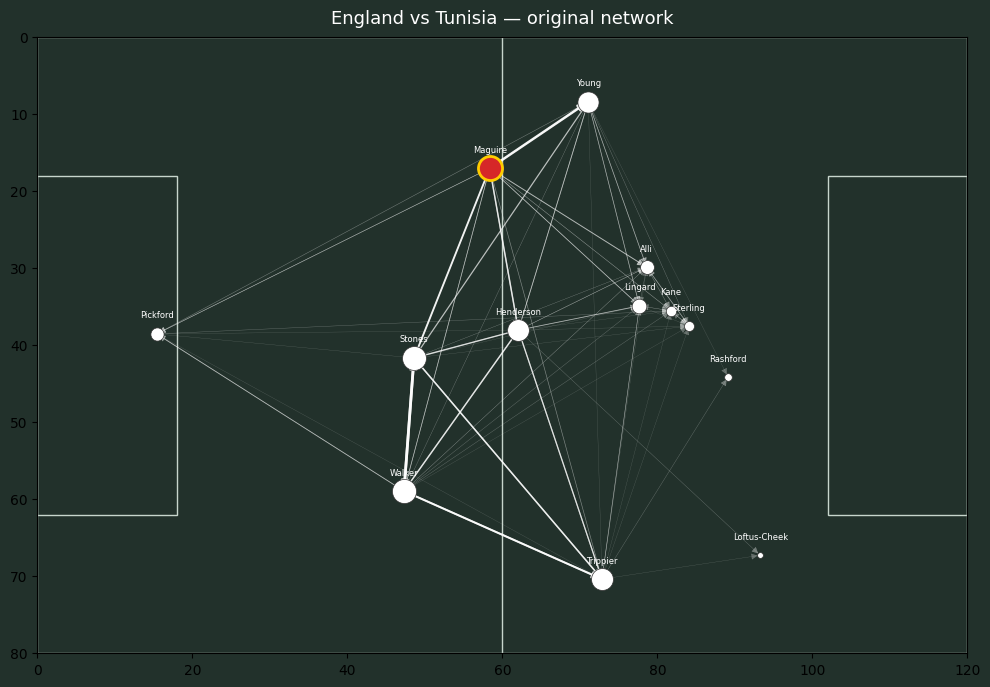

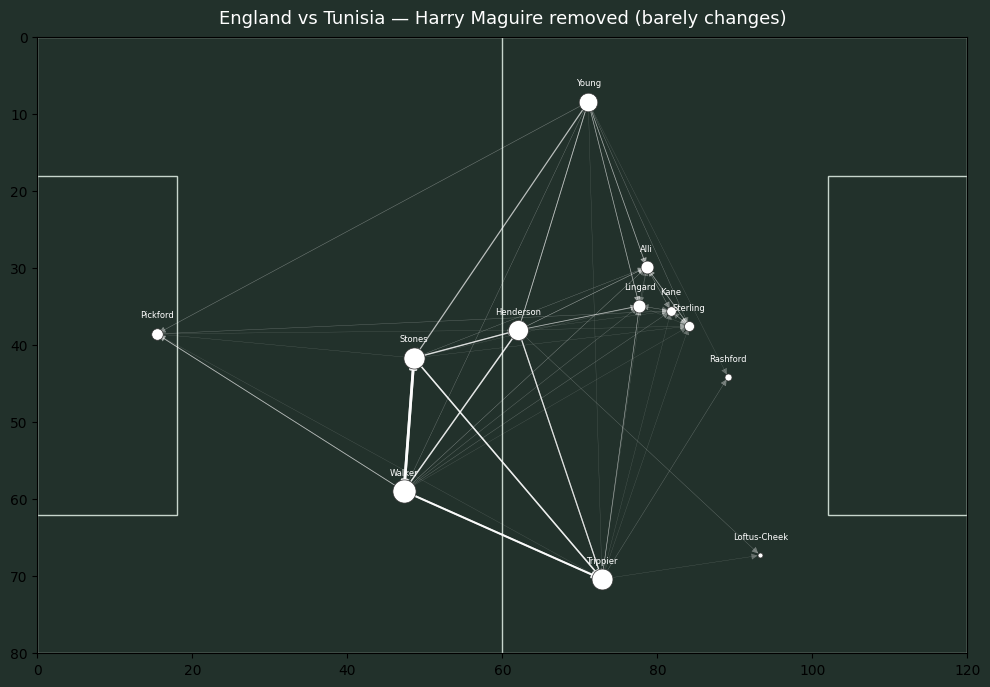

In [8]:
passes_c3 = load_match_team_passes(7537, 'England')
orig_c3 = build_network(passes_c3, 7537, 'England', min_passes=1)
removed_c3 = build_disrupted_network(passes_c3, 7537, 'England', [c3['targeted_player']])

max_deg_c3, max_w_c3 = fixed_scale_refs(orig_c3)
pos_c3 = shared_positions(orig_c3)

f1 = plot_pass_network(
    orig_c3, title='England vs Tunisia — original network',
    min_edge_weight=2, max_out_degree_ref=max_deg_c3, max_edge_weight_ref=max_w_c3,
    node_positions=pos_c3, highlight_players=[c3['targeted_player']],
    save_path=FIG_DIR / '15_case3_original.png',
)
plt.show()
plt.close(f1)

f2 = plot_pass_network(
    removed_c3, title=f"England vs Tunisia — {c3['targeted_player']} removed (barely changes)",
    min_edge_weight=2, max_out_degree_ref=max_deg_c3, max_edge_weight_ref=max_w_c3,
    node_positions=pos_c3,
    save_path=FIG_DIR / '15_case3_removed.png',
)
plt.show()
plt.close(f2)

## Robustness check — are these findings stable, or an artifact of one exact dataset?

Every result so far is computed once, on the observed passes exactly as recorded. A
natural follow-up: if the underlying data had come out slightly differently — the same
match, but with a bit of sampling noise — would the *same* player still be identified as
most critical?

**Method:** bootstrap-resample each team's completed-pass list (same size, drawn with
replacement), rebuild the network, and recompute `efficiency_damage` for the same fixed
set of eligible players. Repeat 500 times per match and record how often each player wins.
A high win-rate means the finding is structurally robust, not a coincidence of the exact
recorded sequence of passes.

Scoped to the two **single-player** case studies (Case 1 and Case 3) — Case 2 is a
pair-level finding, which would need a separate (much more expensive) bootstrap over every
eligible pair per resample rather than every eligible player, and isn't run here.

In [9]:
def eligible_players_for(match_id, team):
    elig = nv._add_eligibility(
        single_player_removal[
            (single_player_removal['match_id'] == match_id) & (single_player_removal['team'] == team)
        ]
    )
    return elig[elig['eligible']]['removed_player'].tolist()


robustness_cases = [
    (8655, 'France', "Case 1 — Kanté"),
    (7537, 'England', "Case 3 — England (robust network)"),
]

bootstrap_results = {}
for mid, team, label in robustness_cases:
    eligible = eligible_players_for(mid, team)
    boot = nv.bootstrap_critical_player_stability(mid, team, eligible, n_boot=500, seed=42)
    summary = nv.summarize_stability(boot)
    bootstrap_results[label] = summary
    print(f"=== {label} ({team}, match {mid}) — {len(eligible)} eligible players, "
          f"{len(boot)} valid resamples ===")
    print(summary.head(5).to_string(index=False))
    print()

=== Case 1 — Kanté (France, match 8655) — 12 eligible players, 500 valid resamples ===
              player  times_critical  stability_pct
        N'Golo Kanté             407           81.4
          Paul Pogba              35            7.0
      Olivier Giroud              20            4.0
Kylian Mbappé Lottin              15            3.0
   Antoine Griezmann              11            2.2



=== Case 3 — England (robust network) (England, match 7537) — 13 eligible players, 500 valid resamples ===
                player  times_critical  stability_pct
           Kyle Walker             257           51.4
       Kieran Trippier             102           20.4
         Harry Maguire              90           18.0
           John Stones              24            4.8
Jordan Brian Henderson              23            4.6



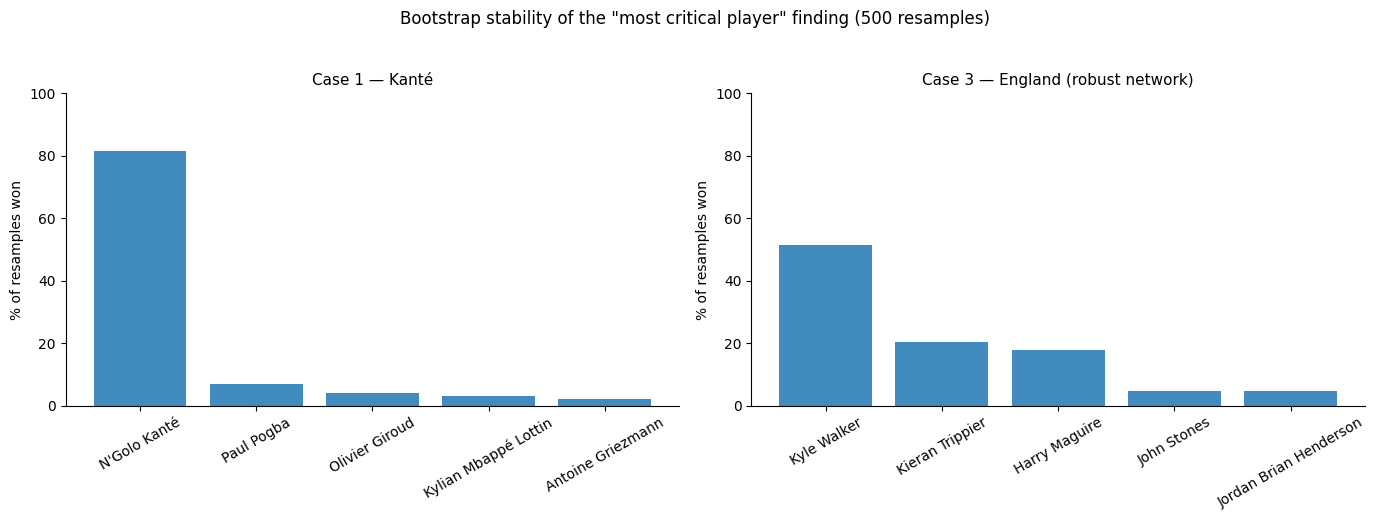

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label, summary) in zip(axes, bootstrap_results.items()):
    top = summary.head(5)
    ax.bar(top['player'], top['stability_pct'], color='#1f77b4', alpha=0.85)
    ax.set_ylim(0, 100)
    ax.set_ylabel('% of resamples won')
    ax.set_title(label, fontsize=11)
    ax.tick_params(axis='x', rotation=30)
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Bootstrap stability of the "most critical player" finding (500 resamples)', y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / '15_bootstrap_stability.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading the two cases side by side:** Kanté's result should be far more stable than
England's — if so, that's not a coincidence. It's the bootstrap independently confirming
each case study's own story: Case 1 claims a *concentrated* dependency (one player the
network structurally relies on), so resampling noise shouldn't be able to dislodge him
often. Case 3 claims a *distributed*, tied structure (three players equally damaging), so
the "winner" should bounce around between them under resampling — instability isn't a
weakness of that finding, it *is* the finding, now shown a second, independent way.

## 5D — Summary framework: individual concentration vs. pair synergy

Every team-match plotted by two axes:
- **X: individual vulnerability concentration** (`top1_top2_gap` — how much worse the
  single most-damaging player is than the next-best)
- **Y: pair synergy** (`best_pair_interaction_effect` — how much more damaging the best
  eligible pair is than the sum of their individual damages would predict)

Quadrant lines are drawn at the median of each axis (x) and at zero (y, since interaction
effect has an intrinsically meaningful sign: synergy vs. redundancy).

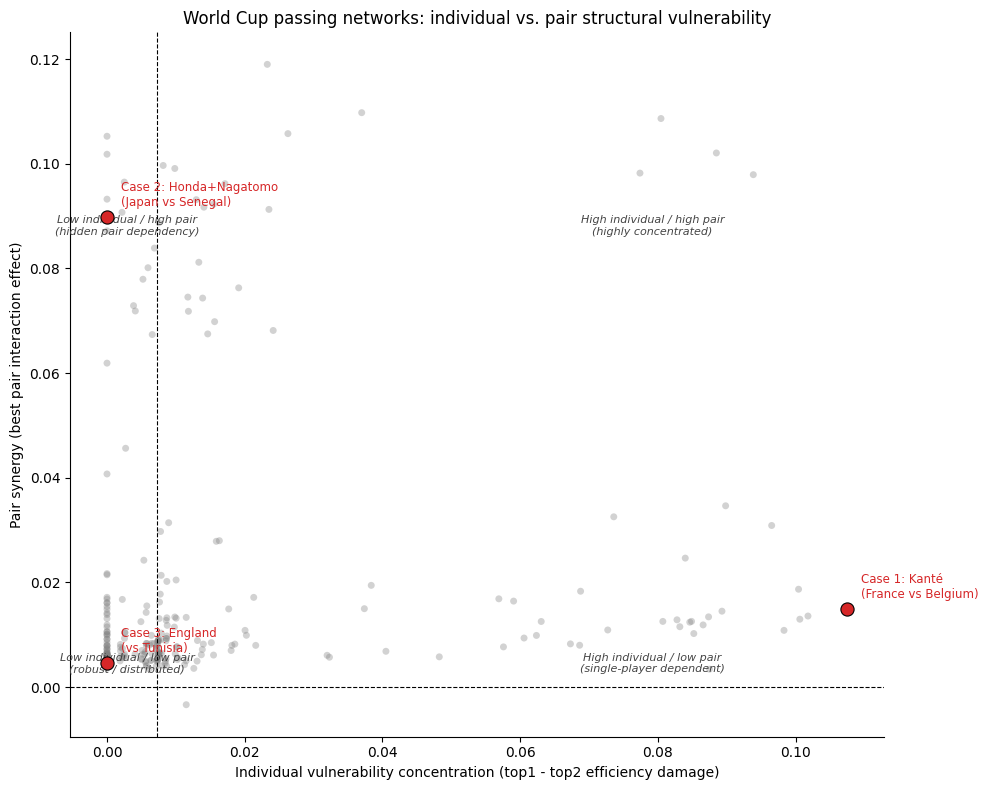

In [11]:
scatter_df = team_match_robustness.merge(
    team_match_pair_vulnerability, on=['match_id', 'team', 'year']
)

x = scatter_df['top1_top2_gap']
y = scatter_df['best_pair_interaction_effect']
x_median = x.median()

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(x, y, s=25, alpha=0.35, color='#7f7f7f', edgecolors='none')

ax.axvline(x_median, color='black', lw=0.8, linestyle='--')
ax.axhline(0, color='black', lw=0.8, linestyle='--')

quadrant_labels = [
    (x_median * 0.4, y.quantile(0.92), 'Low individual / high pair\n(hidden pair dependency)'),
    (x.quantile(0.92), y.quantile(0.92), 'High individual / high pair\n(highly concentrated)'),
    (x_median * 0.4, y.quantile(0.06), 'Low individual / low pair\n(robust / distributed)'),
    (x.quantile(0.92), y.quantile(0.06), 'High individual / low pair\n(single-player dependent)'),
]
for qx, qy, label in quadrant_labels:
    ax.text(qx, qy, label, fontsize=8, color='#444444', ha='center', va='center', style='italic')

# label the 3 case studies
label_points = [
    (8655, 'France', 'Case 1: Kanté\n(France vs Belgium)'),
    (7556, 'Japan', 'Case 2: Honda+Nagatomo\n(Japan vs Senegal)'),
    (7537, 'England', 'Case 3: England\n(vs Tunisia)'),
]
for mid, team, label in label_points:
    row = scatter_df[(scatter_df['match_id'] == mid) & (scatter_df['team'] == team)]
    if row.empty:
        continue
    px, py = row['top1_top2_gap'].iloc[0], row['best_pair_interaction_effect'].iloc[0]
    ax.scatter([px], [py], s=90, color='#d62728', zorder=5, edgecolors='black', linewidths=0.8)
    ax.annotate(label, (px, py), textcoords='offset points', xytext=(10, 8), fontsize=8.5, color='#d62728')

ax.set_xlabel('Individual vulnerability concentration (top1 - top2 efficiency damage)')
ax.set_ylabel('Pair synergy (best pair interaction effect)')
ax.set_title('World Cup passing networks: individual vs. pair structural vulnerability')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / '15_vulnerability_framework_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 5E — Practical interpretation

**Where are World Cup passing networks structurally vulnerable, and are those
vulnerabilities concentrated in obvious stars or hidden combinations of players?**

In [12]:
print('=' * 70)
print('PART 5 SUMMARY')
print('=' * 70)
print()
print('1. Individual vulnerability is often hidden from standard metrics:')
print('   - The most structurally damaging player is the #1 passer only 27% of the time')
print('   - Outside the top 3 passers entirely 43.4% of the time')
print('   - #1 by betweenness centrality only 22.7% of the time')
print("   - Case 1 (Kanté): #2 by pass involvement, only #7 by betweenness, yet the")
print('     single most damaging removal found across the whole dataset (0.128)')
print()
print('2. Some vulnerabilities only exist at the pair level:')
print('   - The true optimal disrupting pair differs from naively combining the two')
print('     individually most-damaging players in 32.8% of team-matches')
print('   - Case 2 (Honda + Nagatomo): ~0 individual damage each, 0.100 jointly —')
print('     roughly 10x the additive expectation')
print()
print('3. Not every network has a choke point:')
print('   - Case 3 (England vs Tunisia): three players tied for most damaging,')
print('     and even the best pair barely exceeds double the single-player damage —')
print('     a genuinely distributed, redundant structure')
print()
print('4. These are three different failure modes, not one story. The practical')
print('   takeaway for a scouting/coaching context: neither raw involvement, nor')
print('   centrality, nor single-player analysis alone reliably finds a team\'s')
print('   structural weak point — some networks need pair-level search to find it,')
print('   and some do not have one to find at all.')

PART 5 SUMMARY

1. Individual vulnerability is often hidden from standard metrics:
   - The most structurally damaging player is the #1 passer only 27% of the time
   - Outside the top 3 passers entirely 43.4% of the time
   - #1 by betweenness centrality only 22.7% of the time
   - Case 1 (Kanté): #2 by pass involvement, only #7 by betweenness, yet the
     single most damaging removal found across the whole dataset (0.128)

2. Some vulnerabilities only exist at the pair level:
   - The true optimal disrupting pair differs from naively combining the two
     individually most-damaging players in 32.8% of team-matches
   - Case 2 (Honda + Nagatomo): ~0 individual damage each, 0.100 jointly —
     roughly 10x the additive expectation

3. Not every network has a choke point:
   - Case 3 (England vs Tunisia): three players tied for most damaging,
     and even the best pair barely exceeds double the single-player damage —
     a genuinely distributed, redundant structure

4. These are thr

## Limitations (carried forward from Parts 1-4, still apply)

- Structural disruption simulation on the *observed* network, not a behavioral
  counterfactual — teammates are not modeled as adapting to a player's absence
- Case studies were selected to illustrate the range of behavior the pipeline finds, not
  as a representative random sample — the summary scatter (5D) is what shows the full
  256-team-match distribution
- `efficiency_damage` and `progressive_capacity_damage` are the only two metrics carried
  through from Part 3 onward (density and largest-component damage were excluded for the
  documented reasons in Part 3)